In [5]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics.pairwise import rbf_kernel
from qiskit.circuit.library import pauli_feature_map
from pennylane.kernels import target_alignment
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [6]:
dataset = pd.read_csv("../dataset/riemann_features.csv")

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
random_forest_features = pd.read_csv("../results/experiment_11/random_forest_feature_selection.csv")["feature"].tolist()
correlation_features = pd.read_csv("../results/experiment_11/correlation_feature_selection.csv")["feature"].tolist()
gevrey_method_features = pd.read_csv("../results/experiment_11/gevrey_method_feature_selection.csv")["feature"].tolist()
mrmr_10_features = pd.read_csv("../results/experiment_11/mrmr_10_features.csv")["feature"].tolist()
mi_features = pd.read_csv("../results/experiment_11/mi_feature_selection.csv")["feature"].tolist()
rank_aggregation_features = pd.read_csv("../results/data_analysis/selected_features.csv")["feature"].tolist()

features_map = {
    "Random Forest": random_forest_features[:10],
    "Correlation": correlation_features[:10],
    "Gevrey Method": gevrey_method_features[:10],
    "MRMR (10 features)": mrmr_10_features,
    "Mutual Information": mi_features,
    "Rank Aggregation": rank_aggregation_features
}

# 2) Training Classical SVR

In [8]:
def run_classical_experiment(features_map):
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    for group_name, features in features_map.items():
        print(f"Running experiment for group: {group_name} with {len(features)} features")

        X_train_subset = X_train[features].to_numpy()
        X_test_subset = X_test[features].to_numpy()

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=5),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_subset)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Group": group_name,
            "RMSE": rmse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": len(features)
        })

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


In [9]:
df_standard = run_classical_experiment(features_map)
print(df_standard)
df_standard.to_csv("../results/experiment_12/classical_results.csv", index=False)

Running experiment for group: Random Forest with 10 features
Running experiment for group: Correlation with 10 features
Running experiment for group: Gevrey Method with 10 features
Running experiment for group: MRMR (10 features) with 10 features
Running experiment for group: Mutual Information with 10 features
Running experiment for group: Rank Aggregation with 10 features
                Group      RMSE        R2  Best C  Best epsilon Best gamma  \
0    Rank Aggregation  0.052026  0.966702       5         0.001        0.1   
1  Mutual Information  0.081191  0.918905       1         0.010      scale   
2  MRMR (10 features)  0.097909  0.882070       5         0.010      scale   
3       Random Forest  0.177213  0.613657       5         0.100      scale   
4       Gevrey Method  0.224403  0.380507       5         0.010       0.01   
5         Correlation  0.265619  0.132043       5         0.500       0.01   

   Features  
0        10  
1        10  
2        10  
3        10  
4     

# 2) Traning Quantum SVR using the same best hyperparameters and features of classical SVR using Angle Embedding

## Verificando melhor kernel

In [10]:
N_QUBITS = 10
dev = qml.device("lightning.qubit", wires=N_QUBITS)


def ansatz_sem_hadamard(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def ansatz_sem_hadamard_XX(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation="X")


def ansatz_com_hadamard(x, wires):
    for w in wires:
        qml.Hadamard(wires=w)
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def ansatz_strong_sem_hadamard(x, wires):
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.StronglyEntanglingLayers(
        weights=np.zeros((1, len(wires), 3)),
        wires=wires
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


def ansatz_strong_com_hadamard(x, wires):
    for w in wires:
        qml.Hadamard(wires=w)
    qml.AngleEmbedding(x, wires=wires, rotation="X")
    qml.StronglyEntanglingLayers(
        weights=np.zeros((1, len(wires), 3)),
        wires=wires
    )
    qml.AngleEmbedding(x, wires=wires, rotation="Y")


@qml.qnode(dev)
def kernel_baseline(x1, x2):
    qml.AngleEmbedding(x1, wires=range(N_QUBITS), rotation="X")
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS), rotation="X")
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_sem_hadamard(x1, x2):
    ansatz_sem_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_sem_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_sem_hadamard_XX(x1, x2):
    ansatz_sem_hadamard_XX(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_sem_hadamard_XX)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_com_hadamard(x1, x2):
    ansatz_com_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_com_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_strong_sem_hadamard(x1, x2):
    ansatz_strong_sem_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_strong_sem_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_strong_com_hadamard(x1, x2):
    ansatz_strong_com_hadamard(x1, wires=range(N_QUBITS))
    qml.adjoint(ansatz_strong_com_hadamard)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


@qml.qnode(dev)
def kernel_iqp(x1, x2):
    qml.IQPEmbedding(x1, wires=range(N_QUBITS))
    qml.adjoint(qml.IQPEmbedding)(x2, wires=range(N_QUBITS))
    return qml.expval(qml.Projector([0] * N_QUBITS, wires=range(N_QUBITS)))


def kernel_rbf_fn(x1, x2):
    return rbf_kernel(x1.reshape(1, -1), x2.reshape(1, -1))[0, 0]


kernels = {
    "Baseline (AngleX sem entanglement)":   kernel_baseline,
    "Basic sem Hadamard":                   kernel_sem_hadamard,
    "Basic sem Hadamard XX":                kernel_sem_hadamard_XX,
    "Basic com Hadamard":                   kernel_com_hadamard,
    "Strong sem Hadamard":                  kernel_strong_sem_hadamard,
    "Strong com Hadamard":                  kernel_strong_com_hadamard,
    "IQP":                                  kernel_iqp,
    "RBF (baseline clássico)":              kernel_rbf_fn,
}


Kernel: Baseline (AngleX sem entanglement)
Geometric difference: 12.3042


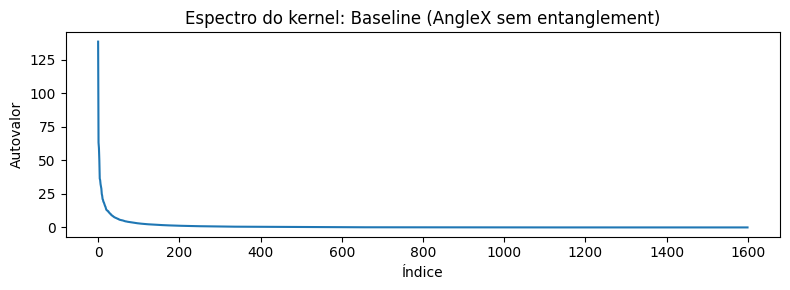

Autovalor máximo: 138.6949
Autovalor mínimo: 0.0001
Razão max/min: 2457476.48

Kernel: Basic sem Hadamard
Geometric difference: 71.6734


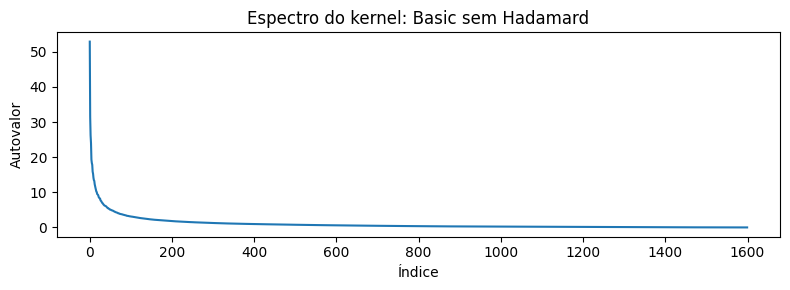

Autovalor máximo: 52.8798
Autovalor mínimo: 0.0031
Razão max/min: 16813.08

Kernel: Basic sem Hadamard XX
Geometric difference: 70.1523


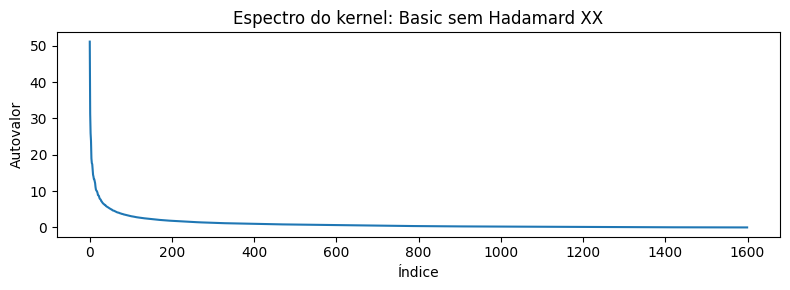

Autovalor máximo: 51.1123
Autovalor mínimo: 0.0029
Razão max/min: 17854.67

Kernel: Basic com Hadamard
Geometric difference: 12.3042


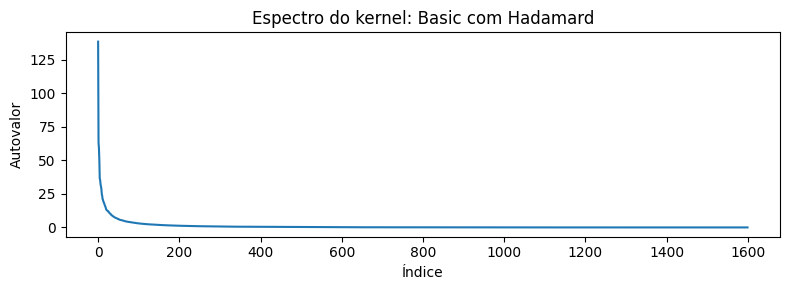

Autovalor máximo: 138.6949
Autovalor mínimo: 0.0001
Razão max/min: 2457476.48

Kernel: Strong sem Hadamard
Geometric difference: 71.6734


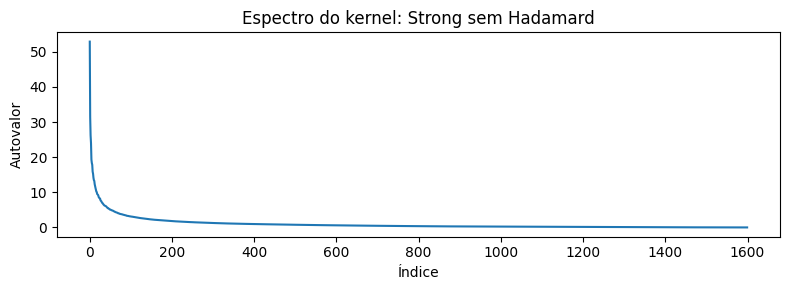

Autovalor máximo: 52.8798
Autovalor mínimo: 0.0031
Razão max/min: 16813.08

Kernel: Strong com Hadamard
Geometric difference: 12.3042


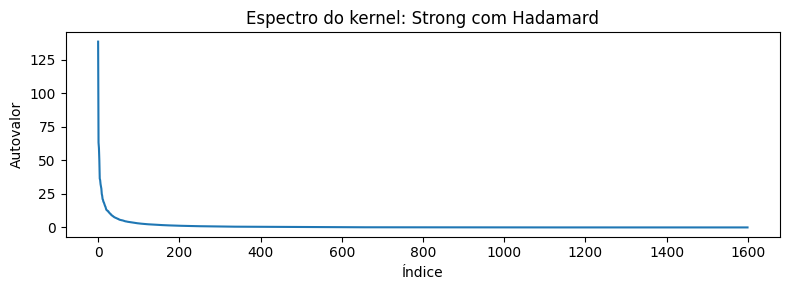

Autovalor máximo: 138.6949
Autovalor mínimo: 0.0001
Razão max/min: 2457476.48

Kernel: IQP
Geometric difference: 184.4553


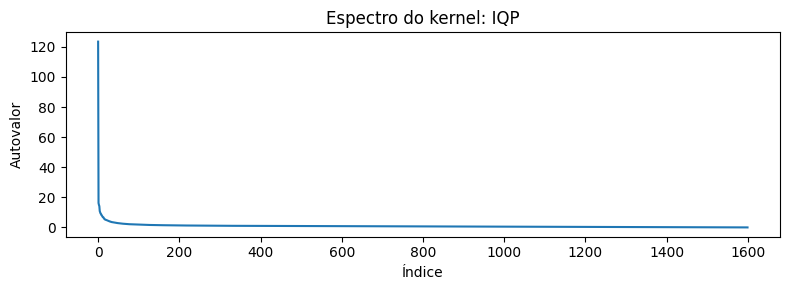

Autovalor máximo: 123.4288
Autovalor mínimo: 0.0135
Razão max/min: 9145.86

Resultados salvos em ../results/experiment_12/spectral_analysis.csv


In [11]:
from scipy.linalg import sqrtm

features = features_map["Rank Aggregation"]
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train[features].to_numpy())


def geometric_difference(K_classical, K_quantum, eps=1e-7):
    """
    Compute geometric difference g between classical and quantum kernels.
    Formula: g = sqrt( || sqrt(K_quantum) @ inv(K_classical) @ sqrt(K_quantum) || )
    """
    N = K_classical.shape[0]

    # Regularize and invert K_classical
    Kc_reg = K_classical + eps * np.eye(N)
    Kc_inv = np.linalg.inv(Kc_reg)

    # Compute the square root of the quantum kernel
    sqrt_Kq = sqrtm(K_quantum)
    # Construct M = sqrt(Kq) @ Kc⁻¹ @ sqrt(Kq)
    M = sqrt_Kq @ Kc_inv @ sqrt_Kq

    # g = sqrt(max eigenvalue of M)
    max_eigval = np.max(np.linalg.eigvalsh(M))
    return np.sqrt(np.maximum(max_eigval, 0.0))


K_rbf = rbf_kernel(X_tr)

spectral_results = []

for name, kernel_func in kernels.items():
    if name == "RBF (baseline clássico)":
        continue

    print(f"\n{'='*60}")
    print(f"Kernel: {name}")
    print(f"{'='*60}")

    K_quantum = qml.kernels.kernel_matrix(X_tr, X_tr, kernel_func)

    g = geometric_difference(K_rbf, K_quantum)
    print(f"Geometric difference: {g:.4f}")

    eigenvalues = np.linalg.eigvalsh(K_quantum)
    eigenvalues_sorted = sorted(eigenvalues, reverse=True)

    plt.figure(figsize=(8, 3))
    plt.plot(eigenvalues_sorted)
    plt.title(f"Espectro do kernel: {name}")
    plt.xlabel("Índice")
    plt.ylabel("Autovalor")
    plt.tight_layout()
    plt.show()

    eig_max = eigenvalues_sorted[0]
    eig_min = eigenvalues_sorted[-1]
    ratio = eig_max / (eig_min + 1e-10)

    print(f"Autovalor máximo: {eig_max:.4f}")
    print(f"Autovalor mínimo: {eig_min:.4f}")
    print(f"Razão max/min: {ratio:.2f}")

    spectral_results.append({
        "Kernel": name,
        "Geometric Difference": g,
        "Eigenvalue Max": eig_max,
        "Eigenvalue Min": eig_min,
        "Eigenvalue Ratio Max/Min": ratio,
    })

df_spectral = pd.DataFrame(spectral_results)
df_spectral.to_csv("../results/experiment_12/spectral_analysis.csv", index=False)
print("\nResultados salvos em ../results/experiment_12/spectral_analysis.csv")

In [12]:
alignments = {}
for name, k in kernels.items():
    print("Calculando alignment para kernel:", name)
    alignment = target_alignment(X_tr, y_train, k, assume_normalized_kernel=True)
    alignments[name] = alignment
    print(f"{name}: {alignment:.4f}")


best = max(alignments, key=alignments.get)
print(f"\nMelhor kernel: {best} (alignment={alignments[best]:.4f})")

Calculando alignment para kernel: Baseline (AngleX sem entanglement)
Baseline (AngleX sem entanglement): 0.3606
Calculando alignment para kernel: Basic sem Hadamard
Basic sem Hadamard: 0.2435
Calculando alignment para kernel: Basic sem Hadamard XX
Basic sem Hadamard XX: 0.2560
Calculando alignment para kernel: Basic com Hadamard
Basic com Hadamard: 0.3606
Calculando alignment para kernel: Strong sem Hadamard
Strong sem Hadamard: 0.2435
Calculando alignment para kernel: Strong com Hadamard
Strong com Hadamard: 0.3606
Calculando alignment para kernel: IQP
IQP: 0.5227
Calculando alignment para kernel: RBF (baseline clássico)
RBF (baseline clássico): 0.5857

Melhor kernel: RBF (baseline clássico) (alignment=0.5857)


## Naive implementation, only rotations in X and standard scaling

In [13]:
results = []
param_grid = {
    "svr__C": [1, 5],
    "svr__epsilon": [0.01, 0.1]
}

features = features_map["Rank Aggregation"]
X_train_subset = X_train[features].to_numpy()
X_test_subset = X_test[features].to_numpy()


for kernel_name, kernel_func in kernels.items():
    if kernel_name == "RBF (baseline clássico)":
        continue
    print(f"Running quantum experiment for group: Rank Aggregation com kernel: {kernel_name}")

    kernel_mat = lambda A, B, kf=kernel_func: qml.kernels.kernel_matrix(A, B, kf)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel=kernel_mat))
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=TimeSeriesSplit(n_splits=5),
    )

    grid.fit(X_train_subset, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_subset)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Experiment": kernel_name,
        "RMSE": rmse,
        "R2": r2,
        "Best C": grid.best_params_["svr__C"],
        "Best epsilon": grid.best_params_["svr__epsilon"],
        "qubits": N_QUBITS,
    })

    print(f"RMSE: {rmse:.4f}, R2: {r2:.4f}, Best C: {grid.best_params_['svr__C']}, Best epsilon: {grid.best_params_['svr__epsilon']}\n")

print(pd.DataFrame(results))
pd.DataFrame(results).to_csv("../results/experiment_12/quantum_results_1.csv", index=False)
print("\nResultados salvos em ../results/experiment_12/quantum_results_1.csv")

Running quantum experiment for group: Rank Aggregation com kernel: Baseline (AngleX sem entanglement)
RMSE: 0.0668, R2: 0.9451, Best C: 1, Best epsilon: 0.01

Running quantum experiment for group: Rank Aggregation com kernel: Basic sem Hadamard


KeyboardInterrupt: 

## Traning Quantum SVR using the same best hyperparameters and features of classical SVR using PauliFeatureMap

In [ ]:
def create_quantum_kernel(n_qubits, reps=3, entanglement="full", paulis=["ZZ", "Z"]):
    feature_map = pauli_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement, paulis=paulis)
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
    return quantum_kernel

In [ ]:
print("Running quantum experiments with Pauli Feature Map\n")

X_train_subset = X_train[features].to_numpy()
X_test_subset = X_test[features].to_numpy()

quantum_kernel = create_quantum_kernel(n_qubits=N_QUBITS, paulis=["ZZ", "ZZZ"], reps=2)

X_train_subset = X_train[features].to_numpy()
X_test_subset = X_test[features].to_numpy()

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel=quantum_kernel.evaluate))
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
)

grid.fit(X_train_subset, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_subset)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results.append({
    "Experiment": "Quantum SVR Pauli Feature Map Kernel",
    "RMSE": rmse,
    "R2": r2,
    "Best C": grid.best_params_["svr__C"],
    "Best epsilon": grid.best_params_["svr__epsilon"],
    "qubits": N_QUBITS,
})

Running quantum experiments with Pauli Feature Map



KeyboardInterrupt: 

In [ ]:
quantum_df = pd.DataFrame(results)
print(quantum_df)
quantum_df.to_csv("../results/experiment_12/quantum_results_2.csv", index=False)